In [1]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from IPython.display import Image, display
from typing import Literal
from langgraph.prebuilt import ToolNode

### Augmented LLM: langchain llm wrapper + tool usage

In [2]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

@tool
def add_vat(amount: float) -> float:
    """Calculate gross price applying 22% VAT
    Args:
        amount: net price
    Returns:
        net price increased by 22%
    """

    return amount * 1.22

llm = ChatOpenAI(
    model="gpt-5.4-mini",
    reasoning_effort="none",
    use_responses_api=True
)
llm_with_tools = llm.bind_tools(
    [add_vat],
    tool_choice="auto"
)

In [3]:
response = llm_with_tools.invoke("A car is 12k€ net price. Calculate gross price")

In [4]:
response

AIMessage(content=[{'arguments': '{"amount":12000}', 'call_id': 'call_ekGp7DGEWEXk7khHQqCPw5tP', 'name': 'add_vat', 'type': 'function_call', 'id': 'fc_0427e1833dc7c91e006a4fa2c35ff881a3aa642af4a1ff3e72', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0427e1833dc7c91e006a4fa2c2ff2081a3afd05f43003b61c7', 'created_at': 1783603907.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_0427e1833dc7c91e006a4fa2c2ff2081a3afd05f43003b61c7', tool_calls=[{'name': 'add_vat', 'args': {'amount': 12000}, 'id': 'call_ekGp7DGEWEXk7khHQqCPw5tP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 20, 'total_tokens': 97, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}})

In [5]:
response.usage_metadata

{'input_tokens': 77,
 'output_tokens': 20,
 'total_tokens': 97,
 'input_token_details': {'cache_read': 0},
 'output_token_details': {'reasoning': 0}}

In [6]:
response.tool_calls

[{'name': 'add_vat',
  'args': {'amount': 12000},
  'id': 'call_ekGp7DGEWEXk7khHQqCPw5tP',
  'type': 'tool_call'}]

NB: we don't get directly the answer from the model, but only the tool_call request

### Agent graph

In [21]:
from typing import Annotated, Any, List
from operator import add

class AgentState(BaseModel):
  query: str
  messages: Annotated[List[Any], add] = []
  answer: str = ""

In [22]:
from jinja2 import Template
from langchain_core.messages import SystemMessage

def agent_node(state: AgentState) -> dict:
  prompt_template = """You are an assistant and you help calculating net/gross prices

## Instructions
- when asked for a gross price, use the tool to calculate
- if you don't have the right tool to run the calculations, say it clearly and don't try to answer

## User query
{{ query }}
"""

  template = Template(prompt_template)
  prompt = template.render(query=state.query)

  response = llm_with_tools.invoke(
      [
          SystemMessage(content=prompt)
      ]
  )

  return {
      "messages": [response]
  }

In [23]:
def tool_router(state: AgentState) -> str:
  if len(state.messages[-1].tool_calls) > 0:
    return "tools"
  else:
    return "end"

In [24]:
vat_agent_graph = (
  StateGraph(AgentState)
  .add_node("tool_node", ToolNode([add_vat]))
  .add_node("agent_node", agent_node)
  .add_edge(START, "agent_node")
  .add_conditional_edges(
    "agent_node",
    tool_router,
    {
      "tools": "tool_node",
      "end": END
    }
  )
  .add_edge("tool_node", END)
  .compile()
)

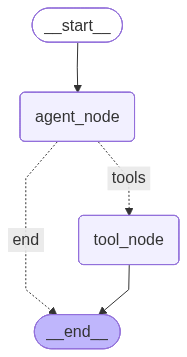

In [25]:
display(Image(vat_agent_graph.get_graph().draw_mermaid_png()))

In [26]:
result = vat_agent_graph.invoke({ "query": "what is the gross price for a 10k€ item?"})

In [27]:
result

{'query': 'what is the gross price for a 10k€ item?',
 'messages': [AIMessage(content=[{'arguments': '{"amount":10000}', 'call_id': 'call_2cUVJEWthGABDdCd0KQXmPcL', 'name': 'add_vat', 'type': 'function_call', 'id': 'fc_090efb9a7a14e517006a4fa33f1aac819fbeb97691ce0aa156', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_090efb9a7a14e517006a4fa33eaee4819fa7dfadce4861e70d', 'created_at': 1783604030.0, 'metadata': {}, 'model': 'gpt-5.4-mini-2026-03-17', 'object': 'response', 'service_tier': 'default', 'status': 'completed', 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17'}, id='resp_090efb9a7a14e517006a4fa33eaee4819fa7dfadce4861e70d', tool_calls=[{'name': 'add_vat', 'args': {'amount': 10000}, 'id': 'call_2cUVJEWthGABDdCd0KQXmPcL', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 133, 'output_tokens': 20, 'total_tokens': 153, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 0}}),
  To